Importation des bibliothèques

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Initialisation des constantes

In [2]:
R_gen = 1.0 #ohm
R_mot = 1.0 #ohm
phi_0 = 0.06 #Wb (constante conservée)
U_ent = np.array([7.15, 13.41, 16.48, 21.19]) #V
I_ent = np.array([1.26, 1.68, 1.83, 2.13]) #A
U_sort = np.array([5.35, 10.45, 12.99, 16.69]) #V
I_sort = np.array([0.238, 0.469, 0.582, 0.750]) #A
Omega = np.array([889, 1760, 2196, 2845]) #tr/min
P_e = np.array([8.9, 22.6, 30.0, 45.1]) # W
P_s = np.array([1.26, 4.9, 7.59, 12.52]) # W

R_mes_int = 1.03    #ohm 
Pperte_tot = P_e - P_s # W
P_cuiv_mot = R_mot * I_ent**2 # W
P_cuiv_gen = R_gen * I_sort**2 # W
P_perte_meca = Pperte_tot - P_cuiv_mot - P_cuiv_gen # W
efficiency = P_s / P_e 
couple_utile = ((U_sort * I_sort)+R_gen * I_sort**2 + P_perte_meca/2) / (Omega * (2 * np.pi / 60)) # Nm

Calculs des pertes méca en fonction de la vitesse de rotation

Text(0, 0.5, 'Puissance mécanique perdue')

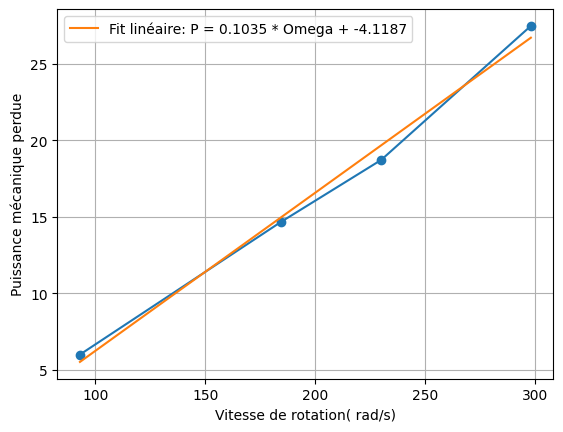

In [3]:
plt.plot(Omega*2*np.pi/60, P_perte_meca, marker='o')
coeffs = np.polyfit(Omega*2*np.pi/60, P_perte_meca, 1)
plt.plot(Omega*2*np.pi/60, np.polyval(coeffs, Omega*2*np.pi/60), label=f'Fit linéaire: P = {coeffs[0]:.4f} * Omega + {coeffs[1]:.4f}')
plt.legend()
plt.grid()
plt.xlabel("Vitesse de rotation( rad/s)")
plt.ylabel("Puissance mécanique perdue")

Attribution équitable des pertes entre les deux moteurs -> Déduction des pertes sur un moteur

In [4]:
def P_meca_1_mot(Omega):
    return (coeffs[0] * Omega + coeffs[1])/2

Importation des données

In [5]:
T1,I_mes,T2,V_mes = np.loadtxt("9_7mm_12_3V.csv", delimiter=";",skiprows=1, unpack=True)
I1 = I_mes*R_mes_int
V1 = V_mes*2 #coeff division par 2

Fonction de lissage des valeurs expérimentales

In [6]:
#Moyenne glissante
def lisser(signal_brut,L):
    res = np.copy(signal_brut) 
    for i in range (1,len(signal_brut)-1): # toutes les valeurs sauf la première et la dernière
        L_g = min(i,L) # nombre de valeurs disponibles à gauche
        L_d = min(len(signal_brut)-i-1,L) # nombre de valeurs disponibles à droite
        Li=min(L_g,L_d)
        res[i]=np.sum(signal_brut[i-Li:i+Li+1])/(2*Li+1)
    return res

Découpe du lissage en deux parties pour ne pas subir les grosses variations de vitesses

In [7]:
#n=890 #13mm_8_2V
#n=940 #12_6mm_12_3V
n=940 #9_7mm_12_3V
#n=840 #8_9mm_12_3V
#n=870 #7mm_12_3V
#n=650 #10_5mm_12_3V
#n=600 #11_5mm_12_3V
#n=730 #10_3mm_12_3V
#n=750 #11_8mm_12_3V
#n=1300 #12mm_12_3V
#n=1650 #8mm_12_3V
#n=1235 #7_7mm_12_3V
#n=1000 #7_5mm_12_3V
#n=1200 #6_5mm_12_3V
#n=1080 #8_1mm_12_3V
#n=1480 #9_5mm_12_3V

Tension_liss = lisser(V1[:n],40)

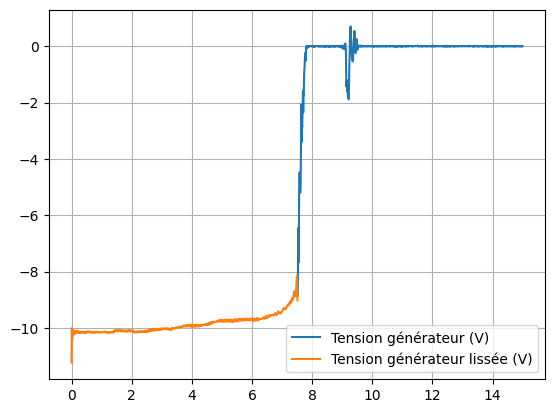

In [8]:
plt.plot(T2[n:],V1[n:], label='Tension générateur (V)')
plt.plot(T2[:n], Tension_liss, label='Tension générateur lissée (V)')
plt.legend()
plt.grid()

Finalisation du traitement de la tension

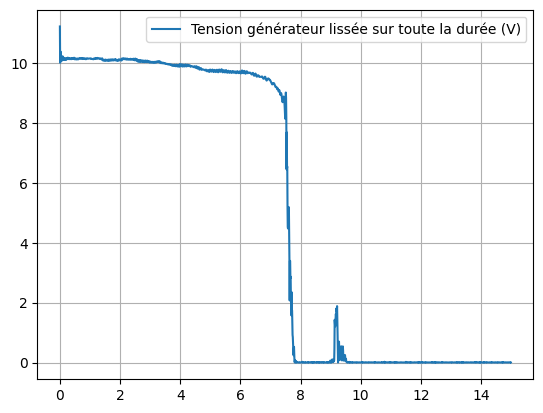

In [9]:
Tension_fin = np.concatenate((np.abs(Tension_liss), np.abs(V1[n:])), axis=0)
plt.plot(T2,Tension_fin, label='Tension générateur lissée sur toute la durée (V)')
plt.grid()
plt.legend()

Calcul de la vitesse de rotation

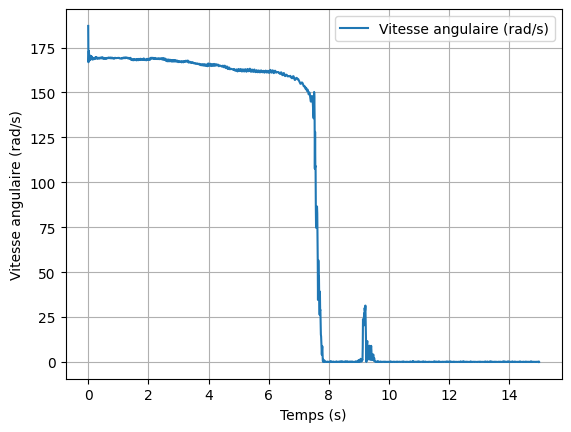

In [10]:
Omega = Tension_fin / phi_0
plt.plot(T2, Omega, label='Vitesse angulaire (rad/s)')
plt.xlabel('Temps (s)')
plt.ylabel('Vitesse angulaire (rad/s)')
plt.grid()
plt.legend()

Lissage de l'intensité

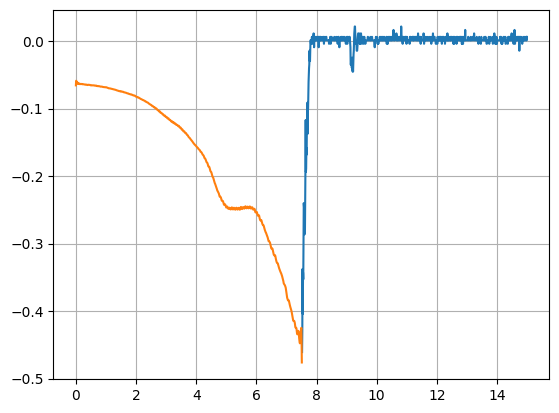

In [11]:
Intensite_liss = lisser(I1[:n],30)
plt.plot(T2[n:],I1[n:], label='Courant générateur (A)')
plt.plot(T2[:n], Intensite_liss, label='Courant générateur lissé (A)')
plt.grid()

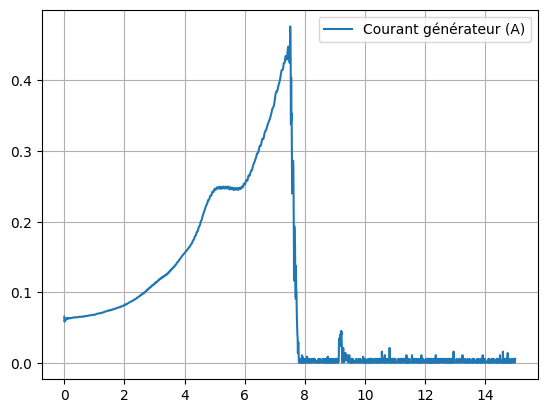

In [12]:
Intensite_fin = np.concatenate((np.abs(Intensite_liss), np.abs(I1[n:])), axis=0)
plt.plot(T2, Intensite_fin, label='Courant générateur (A)')

plt.grid()
plt.legend()


Estimation du couple brut

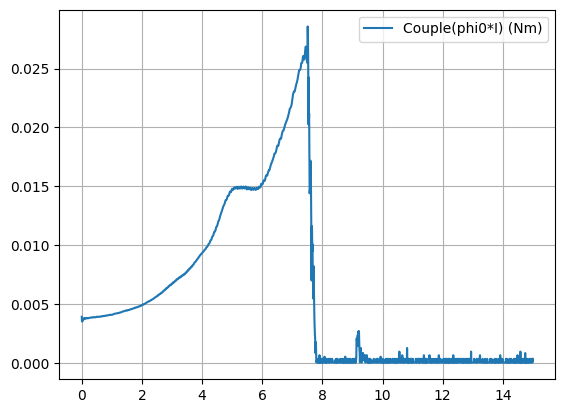

In [13]:
plt.plot(T2, phi_0*Intensite_fin, label='Couple(phi0*I) (Nm)')
plt.grid()
plt.legend()

Calcul et affichage du couple transmis

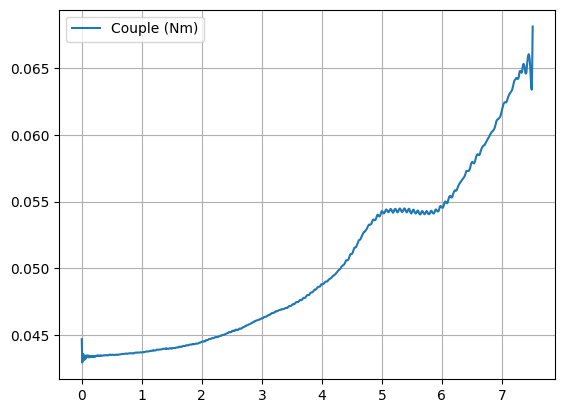

In [15]:
Cpl = ((Tension_fin[:n] * Intensite_fin[:n])+R_gen * Intensite_fin[:n]**2 + P_meca_1_mot(Omega[:n])) / (Omega[:n])
plt.plot(T2[:n], Cpl, label='Couple (Nm)')

plt.grid()
plt.legend()

Text(0.5, 1.0, 'Couple max en fonction de la distance (S2)')

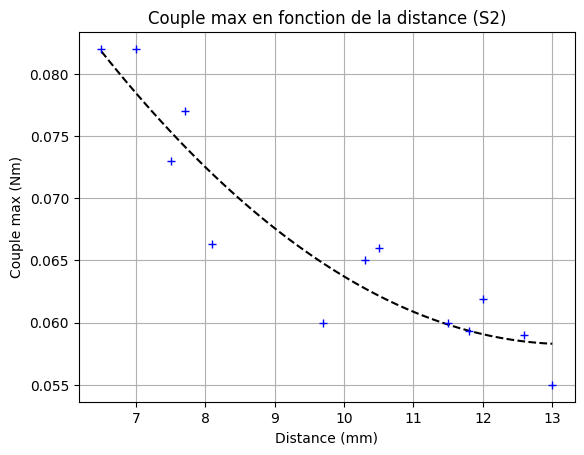

In [16]:
#d = [6.5 ,7, 7.5,7.7,8,8.1,8.9, 9.5, 9.7,10.3, 10.5, 11.5, 11.8, 12, 12.6, 13.] # mm
#C_max = [0.082, 0.082, 0.073,0.077,0.097,0.0663, 0.084, 0.0879,0.06, 0.065,0.066, 0.06,0.0593, 0.0619, 0.059, 0.055] # Nm
d = [6.5 ,7, 7.5,7.7,8.1,9.7,10.3, 10.5, 11.5, 11.8, 12, 12.6, 13.] # mm
C_max = [0.082, 0.082, 0.073,0.077,0.0663, 0.06, 0.065,0.066, 0.06,0.0593, 0.0619, 0.059, 0.055] # Nm
coeffs_2 = np.polyfit(d, C_max, 2)
plt.plot(np.linspace(min(d), max(d), 100), np.polyval(coeffs_2, np.linspace(min(d), max(d), 100)),"k--", label=f'Fit quadratique: C = {coeffs_2[0]:.4f} * d^2 + {coeffs_2[1]:.4f} * d + {coeffs_2[2]:.4f}')
plt.plot(d, C_max, 'b+', label='Couple max en fonction de la distance (Nm)')
plt.xlabel('Distance (mm)')
plt.ylabel('Couple max (Nm)')
plt.grid()
plt.title('Couple max en fonction de la distance (S2)')

Tracer du graphique du couple maximum en fonction de la distance

In [17]:
# Distance (mm) - LL_D1_Distance3
distances = [
    3, 4, 5, 6, 7, 8, 9.0, 10, 11, 12, 
    13.0, 14, 15
]

# Couple de torsion axial
couple_3 = [
    0.07632234346086758, 0.05462097886641405, 0.04584659111888399, 
    0.03419906309874077, 0.03460649966710709, 0.03269227993603088, 
    0.021067441860043338, 0.01965901188295399, 0.020210878704810017, 
    0.022432348687646035, 0.017367025514510442, 0.012695259266419392, 
    0.005166019092506739
]


In [18]:
distances = [
    3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 
    13, 14, 15
]

couple_2 = [
    0.07574594275729812, 0.058365533960335475, 0.045041359961150704, 
    0.037299427794236305, 0.03279477181819897, 0.027215774403260527, 
    0.030437249616167023, 0.02255440167886754, 0.02267163589789973, 
    0.019682948655312976, 0.014764459287564063, 0.013879001427401564, 
    0.011074010218424912
]

In [19]:
def model_torque_distance(d, A, B):
    return A/d**B

fit_distance, _ = curve_fit(model_torque_distance, distances, couple_2)
A_fit, B_fit = fit_distance
print(f"Paramètres du modèle de distance : A = {A_fit:.4f}, B = {B_fit:.4f}")

Paramètres du modèle de distance : A = 0.2343, B = 1.0172


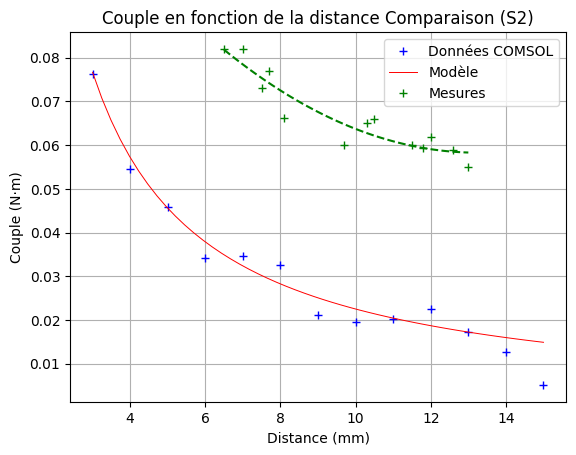

In [20]:

plt.plot(distances, couple_3,'+', color='b', label='Données COMSOL')
plt.plot(np.linspace(min(distances), max(distances)), model_torque_distance(np.linspace(min(distances), max(distances)), *fit_distance), color='r', label='Modèle', lw=0.7)
plt.plot(d, C_max,'+', color='g', label='Mesures')
plt.plot(np.linspace(min(d), max(d), 100), np.polyval(coeffs_2, np.linspace(min(d), max(d), 100)),"g--")
plt.title('Couple en fonction de la distance Comparaison (S2)')
plt.xlabel('Distance (mm)')
plt.ylabel('Couple (N·m)')
plt.grid(True)
plt.legend()
plt.show()